# creating a loan approval ml model

In [28]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [94]:
#importing dataset
df = pd.read_csv("loan_approval_data.csv")

In [95]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [97]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [98]:
num_cols = df.select_dtypes(include = ["number"]).columns

In [99]:
cat_cols = df.select_dtypes(include = ["object"]).columns

In [100]:
num_cols.shape

(12,)

In [103]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")

df[num_cols] = num_imp.fit_transform(data[num_cols])


In [104]:
cat_imp = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imp.fit_transform(data[cat_cols])

In [105]:
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [106]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# eda

In [107]:
count_loan_approved = df["Loan_Approved"].value_counts()

In [108]:
count_loan_approved

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1abebaa0550>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'Yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

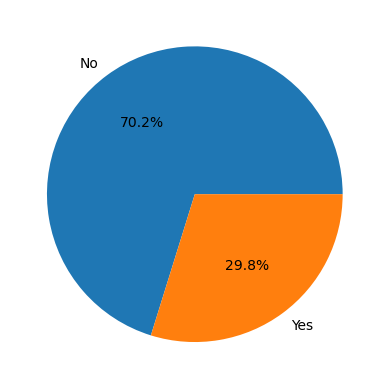

In [109]:
plt.pie(count_loan_approved,labels=["No","Yes"],autopct="%1.1f%%")

[Text(0, 0, '722'), Text(0, 0, '278')]

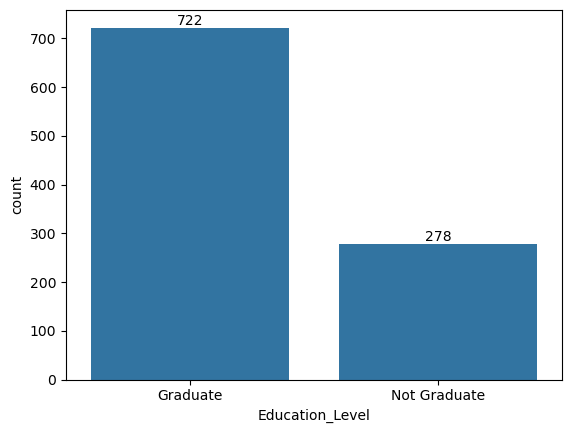

In [110]:
edu_cnt = df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

In [111]:
cat_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

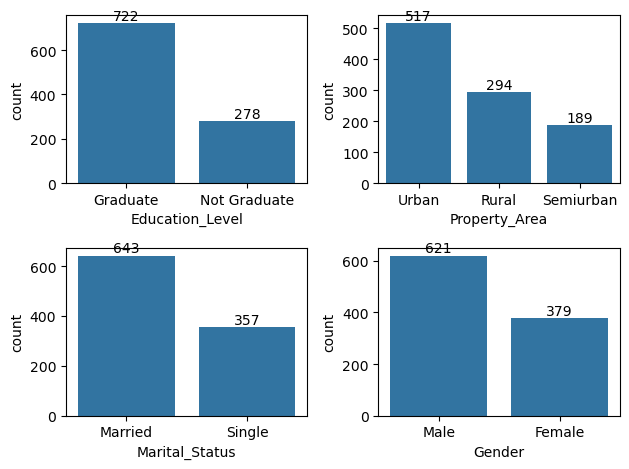

In [112]:
cols = ["Education_Level","Property_Area","Marital_Status","Gender"]

fig, axes = plt.subplots(2,2)

count = 0
for i in range (2):
    for j in range (2):
        
        edu_cnt = df[cols[count]].value_counts()
        a=sns.barplot(edu_cnt,ax=axes[i][j])
        a.bar_label(a.containers[0])
        count = count +1

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

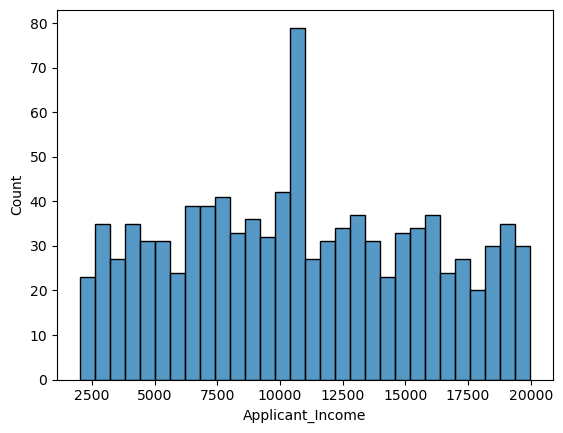

In [117]:
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins=30
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

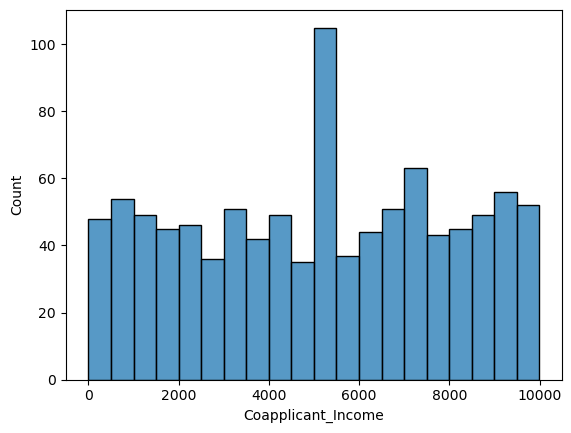

In [119]:
sns.histplot(
    data=df,
    x = "Coapplicant_Income",
    bins=20
)

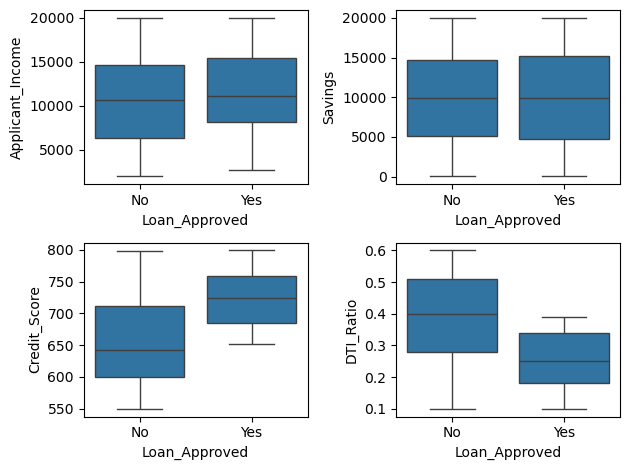

In [125]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0][0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax = axes[0][1],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax = axes[1][0],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax = axes[1][1],data=df,x="Loan_Approved",y="DTI_Ratio")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

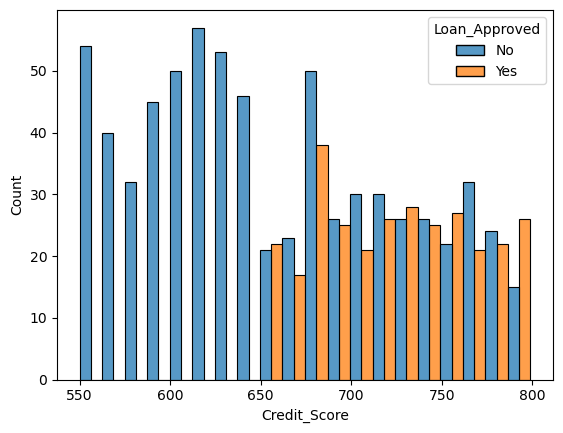

In [126]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

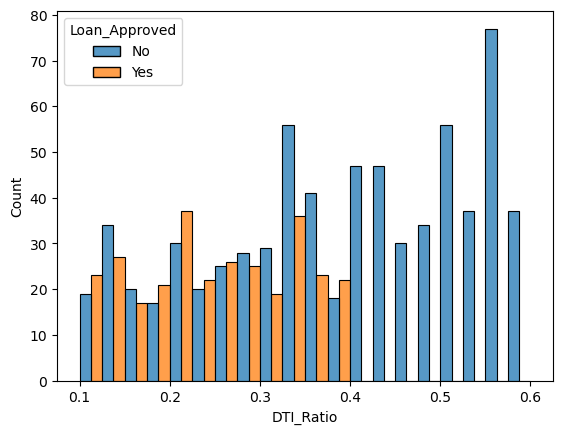

In [127]:
sns.histplot(
    data=df,
    x="DTI_Ratio",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [129]:
df = df.drop("Applicant_ID",axis=1)

In [130]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [131]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [135]:
nums_cols = df.select_dtypes("number")
corr_matrix = nums_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


<Axes: >

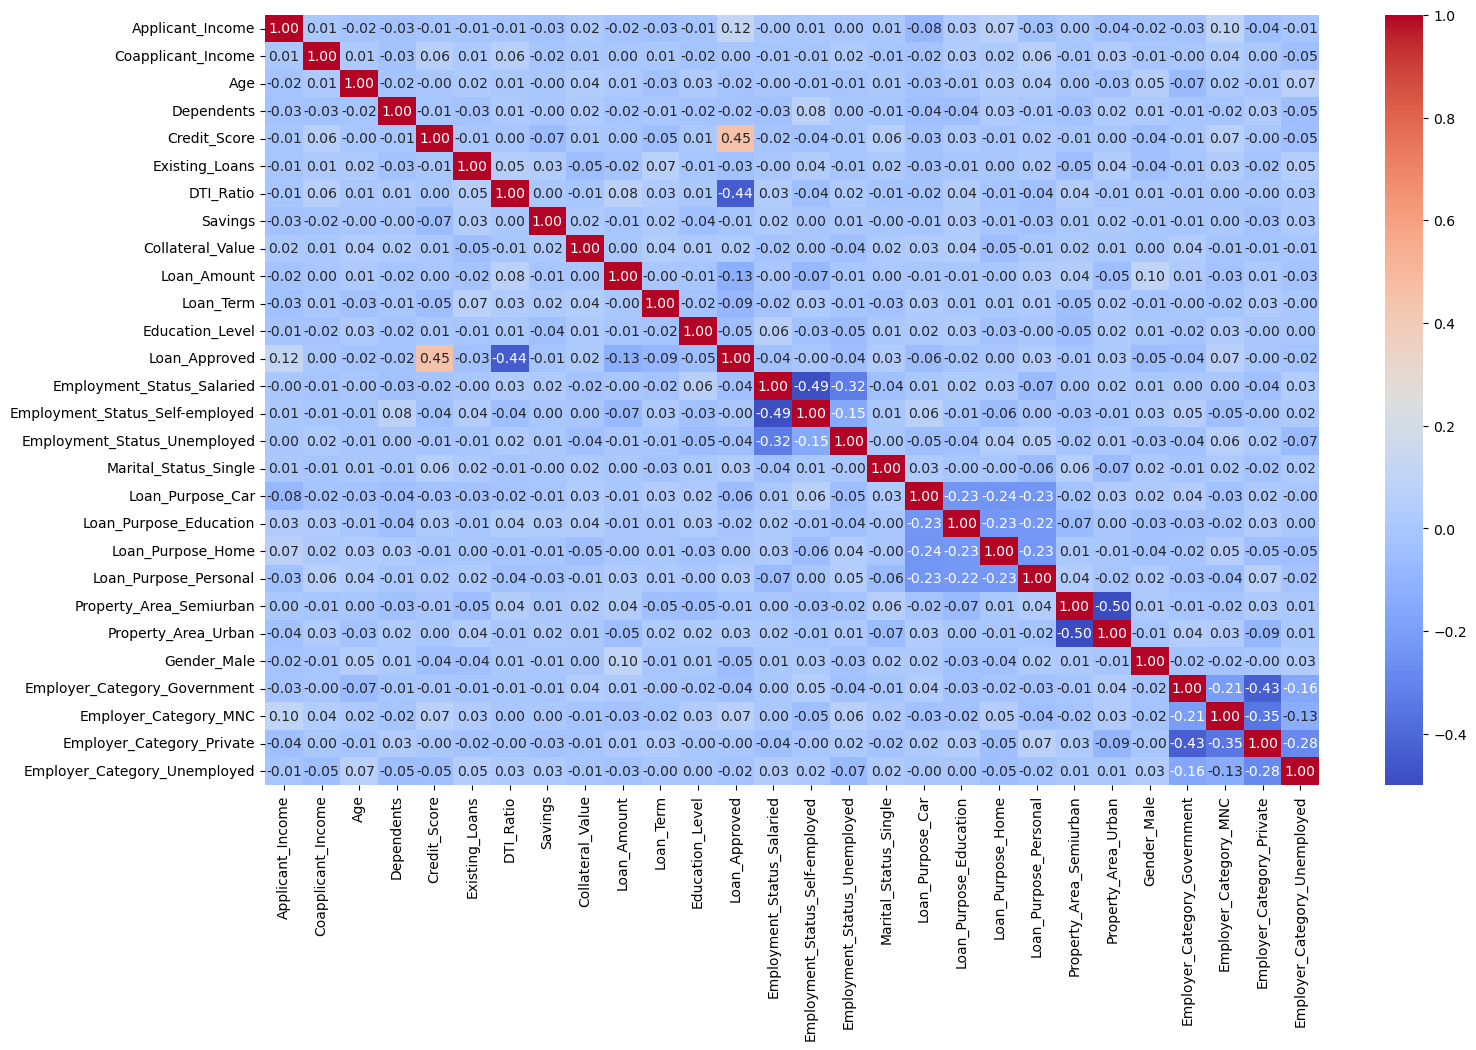

In [138]:
plt.figure(figsize=(17, 10))
sns.heatmap(
    data = corr_matrix,
    annot=True,
    fmt=".2f",
    cmap = "coolwarm"
)

In [139]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1 score:  0.7768595041322314
Accuracy:  0.865
[[126  13]
 [ 14  47]]


In [147]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.6274509803921569
Recall:  0.5245901639344263
F1 score:  0.5714285714285714
Accuracy:  0.76
[[120  19]
 [ 29  32]]


In [148]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1 score:  0.7692307692307693
Accuracy:  0.865
[[128  11]
 [ 16  45]]


In [149]:
from sklearn.model_selection import GridSearchCV

classifier = KNeighborsClassifier()
param_grid = {"n_neighbors":[3,5,7,9,11]}

model = GridSearchCV(
    classifier,
    param_grid,
    cv = 5
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("KNN_cv")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))

KNN_cv
Precision:  0.6585365853658537
Recall:  0.4426229508196721
F1 score:  0.5294117647058824
Accuracy:  0.76
[[125  14]
 [ 34  27]]


In [150]:
res = pd.DataFrame(model.cv_results_)
print(res)

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.002244      0.001313         0.008565        0.002160   
1       0.001174      0.000214         0.006418        0.001507   
2       0.001218      0.000168         0.005168        0.000610   
3       0.001497      0.000253         0.005551        0.000260   
4       0.001108      0.000219         0.005464        0.000462   

   param_n_neighbors               params  split0_test_score  \
0                  3   {'n_neighbors': 3}            0.78125   
1                  5   {'n_neighbors': 5}            0.81875   
2                  7   {'n_neighbors': 7}            0.83125   
3                  9   {'n_neighbors': 9}            0.81250   
4                 11  {'n_neighbors': 11}            0.78750   

   split1_test_score  split2_test_score  split3_test_score  split4_test_score  \
0            0.73125            0.76875            0.78750            0.74375   
1            0.71250            0.78750           